# Exp04. Size Ablation Only


- 선택된 위치에서 size ratio `[0.15, 0.20, 0.25, 0.30, 0.35]`에 대해 normal sticker와 adversarial sticker를 비교한다.


In [1]:
# ============================================================
# Cell 0. Dependency Installation
# ============================================================

INSTALL_DEPENDENCIES = True

if INSTALL_DEPENDENCIES:
    !pip -q uninstall -y transformers tokenizers huggingface_hub facenet-pytorch
    !pip -q install \
        "transformers==4.45.2" \
        "tokenizers>=0.20,<0.21" \
        "huggingface_hub>=0.23.2" \
        "safetensors" \
        "omegaconf" \
        "timm" \
        "fvcore" \
        "scikit-learn" \
        "matplotlib" \
        "pandas" \
        "tqdm"
    !pip -q install facenet-pytorch --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 140.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 58.8 MB/s eta 0:00:00


In [2]:
# ============================================================
# Cell 1. Imports, Config, Output Paths
# ============================================================

import os
import sys
import json
import math
import random
from pathlib import Path
from collections import defaultdict
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF

from sklearn.datasets import fetch_lfw_people
from huggingface_hub import snapshot_download
from transformers import AutoModel
from tqdm.auto import tqdm

from google.colab import drive
drive.mount("/content/drive")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

MODEL_NAME = "minchul/cvlface_adaface_ir101_webface12m"
MODEL_SHORT_NAME = "adaface_ir101_wf12m"

NUM_IDENTITIES = 100
MIN_FACES_PER_PERSON = 5
ENROLL_IMAGES_PER_ID = 1
MAX_PROBES_PER_ID = 8
TARGET_FAR = 0.01

BATCH_SIZE = 64
NUM_WORKERS = 0

DRIVE_ROOT = Path("/content/drive/MyDrive")
MASCOT_PATH = DRIVE_ROOT / "SafeAI-final-project/mask/puang.png"

EXP04_SIZE_RATIOS = [0.15, 0.20, 0.25, 0.30, 0.35]

ATTACK_STEPS = 1000
ATTACK_BATCH_SIZE = 32
ATTACK_LR = 0.05

TAU = 0.05
MARGIN = 0.05
THRESHOLD_MARGIN = 0.00
LAMBDA_TRUE = 1.0
LAMBDA_IMP = 2.0
LAMBDA_THRESH = 2.0
LAMBDA_RANK = 1.0
TV_WEIGHT = 0.0

RUN_TAG = datetime.now(ZoneInfo("Asia/Seoul")).strftime("run_%Y%m%d_%H%M%S")
PROJECT_DRIVE_DIR = DRIVE_ROOT / "SafeAI-final-project" / "output"

EXP04_ROOT = PROJECT_DRIVE_DIR / "exp04_size_ablation_only_color_lfw"
EXP04_DIR = EXP04_ROOT / MODEL_SHORT_NAME / RUN_TAG
EXP04_PREREQ_DIR = EXP04_DIR / "prereq_clean_baseline"
EXP04_DETAIL_DIR = EXP04_DIR / "details"
EXP04_FIG_DIR = EXP04_DIR / "figures"
EXP04_PATCH_DIR = EXP04_DIR / "patches"
EXP04_HISTORY_DIR = EXP04_DIR / "histories"
EXP04_PROCESS_DIR = EXP04_DIR / "process_visuals"

for d in [
    EXP04_DIR,
    EXP04_PREREQ_DIR,
    EXP04_DETAIL_DIR,
    EXP04_FIG_DIR,
    EXP04_PATCH_DIR,
    EXP04_HISTORY_DIR,
    EXP04_PROCESS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("RUN_TAG:", RUN_TAG)
print("EXP04_DIR:", EXP04_DIR)

if not Path(MASCOT_PATH).exists():
    raise FileNotFoundError(f"MASCOT_PATH가 존재하지 않음: {MASCOT_PATH}")

Mounted at /content/drive
DEVICE: cuda
RUN_TAG: run_20260615_141704
EXP04_DIR: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704


In [3]:
# ============================================================
# Cell 2. Set Exp04 Location Manually
# ============================================================
# Exp03 결과:
# best_location = nose_bridge
# best_misaccept_rate = 0.28664495114006516
# patch_size_ratio = 0.30
# patch_size_px = 34

EXP04_LOCATION = "nose_bridge"

exp03_best_info = {
    "best_location": "nose_bridge",
    "best_misaccept_rate": 0.28664495114006516,
    "patch_size_ratio": 0.30,
    "patch_size_px": 34,
    "model_short_name": MODEL_SHORT_NAME,
    "note": "manual_hardcoded_from_exp03_result",
}

print("Using hardcoded Exp03 best info:")
print(json.dumps(exp03_best_info, indent=2, ensure_ascii=False))
print("EXP04_LOCATION:", EXP04_LOCATION)

with open(EXP04_DIR / "04_exp03_best_location_used.json", "w", encoding="utf-8") as f:
    json.dump({
        "exp04_location": EXP04_LOCATION,
        "source_json": None,
        "exp03_best_info": exp03_best_info,
        "run_tag": RUN_TAG,
    }, f, ensure_ascii=False, indent=2)

Using hardcoded Exp03 best info:
{
  "best_location": "nose_bridge",
  "best_misaccept_rate": 0.28664495114006516,
  "patch_size_ratio": 0.3,
  "patch_size_px": 34,
  "model_short_name": "adaface_ir101_wf12m",
  "note": "manual_hardcoded_from_exp03_result"
}
EXP04_LOCATION: nose_bridge


In [4]:
# ============================================================
# Cell 3. Image Utilities
# ============================================================

preprocess = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

def numpy_face_to_pil(img):
    img = np.asarray(img)
    if img.ndim == 3 and img.shape[0] in [1, 3] and img.shape[-1] not in [1, 3]:
        img = np.transpose(img, (1, 2, 0))
    if np.issubdtype(img.dtype, np.floating):
        img = np.nan_to_num(img)
        if img.max() <= 1.5:
            img = img * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)
    else:
        img = np.clip(img, 0, 255).astype(np.uint8)
    if img.ndim == 2:
        return Image.fromarray(img, mode="L").convert("RGB")
    return Image.fromarray(img).convert("RGB")

def pil_to_model_tensor(pil):
    return preprocess(pil.convert("RGB"))

def tensor_to_pil(x):
    x = x.detach().cpu().clamp(-1, 1)
    x = (x * 0.5 + 0.5).clamp(0, 1)
    return TF.to_pil_image(x)

def show_pil_grid(images, titles=None, ncols=5, figsize=(12, 6), save_path=None):
    n = len(images)
    if n == 0:
        print("No images to show.")
        return
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(img)
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i], fontsize=9)
    plt.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

def save_patch_png(patch, mask, path):
    patch = patch.detach().cpu().clamp(-1, 1)
    mask = mask.detach().cpu().clamp(0, 1)
    rgb = (patch[0] * 0.5 + 0.5).clamp(0, 1)
    alpha = mask[0].clamp(0, 1)
    rgba = torch.cat([rgb, alpha], dim=0)
    pil = TF.to_pil_image(rgba)
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    pil.save(path)
    print("Saved:", path)

Detect landmarks for enroll_items:   0%|          | 0/100 [00:00<?, ?it/s]

enroll_items: mtcnn=99, fallback=1


Detect landmarks for probe_items:   0%|          | 0/629 [00:00<?, ?it/s]

probe_items: mtcnn=627, fallback=2
Enrollment images: 100
Probe images: 629
Identities: 100
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/process_visuals/04_landmark_detection_samples.png


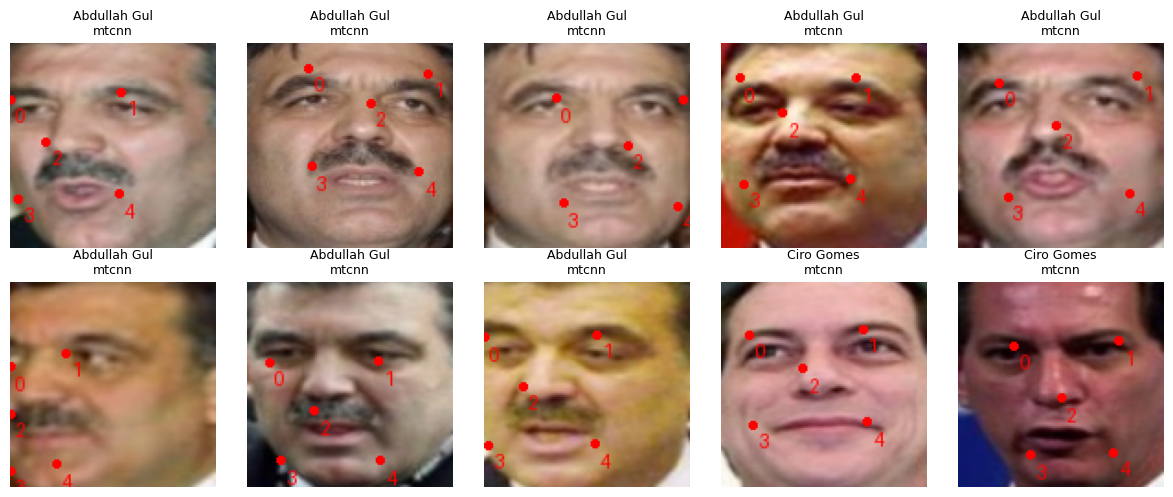

In [5]:
# ============================================================
# Cell 4. Dataset and Landmark Detection
# ============================================================

try:
    from facenet_pytorch import MTCNN
except ImportError:
    !pip -q install facenet-pytorch --no-deps
    from facenet_pytorch import MTCNN

USE_LANDMARK_BASED_PLACEMENT = True
LANDMARK_FALLBACK_TO_CANONICAL = True

CANONICAL_LANDMARKS_112 = np.array([
    [38.0, 42.0],
    [74.0, 42.0],
    [56.0, 60.0],
    [42.0, 78.0],
    [70.0, 78.0],
], dtype=np.float32)

class FaceDataset(Dataset):
    def __init__(self, items):
        self.items = list(items)
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        item = self.items[idx]
        landmarks = item.get("landmarks", CANONICAL_LANDMARKS_112)
        return {
            "image": pil_to_model_tensor(item["pil"]),
            "identity": item["identity"],
            "index": idx,
            "role": item.get("role", "unknown"),
            "local_index": item.get("local_index", -1),
            "lfw_index": item.get("lfw_index", -1),
            "landmarks": torch.tensor(landmarks, dtype=torch.float32),
            "landmark_source": item.get("landmark_source", "unknown"),
        }

def load_lfw_items(num_identities=NUM_IDENTITIES, min_faces_per_person=MIN_FACES_PER_PERSON):
    lfw = fetch_lfw_people(min_faces_per_person=min_faces_per_person, resize=1.0, color=True, funneled=True)
    by_id = defaultdict(list)
    for idx, img in enumerate(lfw.images):
        identity = str(lfw.target_names[lfw.target[idx]])
        pil = numpy_face_to_pil(img)
        by_id[identity].append({"identity": identity, "pil": pil, "lfw_index": idx})
    eligible = [(identity, imgs) for identity, imgs in by_id.items() if len(imgs) >= ENROLL_IMAGES_PER_ID + 1]
    eligible = sorted(eligible, key=lambda x: x[0])
    rng = np.random.default_rng(SEED)
    rng.shuffle(eligible)
    selected = eligible[:num_identities]
    enroll_items, probe_items = [], []
    for identity, imgs in selected:
        imgs = list(imgs)
        rng.shuffle(imgs)
        enroll_imgs = imgs[:ENROLL_IMAGES_PER_ID]
        probe_imgs = imgs[ENROLL_IMAGES_PER_ID:ENROLL_IMAGES_PER_ID + MAX_PROBES_PER_ID]
        for j, face_item in enumerate(enroll_imgs):
            enroll_items.append({"identity": identity, "pil": face_item["pil"], "lfw_index": face_item["lfw_index"], "role": "enroll", "local_index": j})
        for j, face_item in enumerate(probe_imgs):
            probe_items.append({"identity": identity, "pil": face_item["pil"], "lfw_index": face_item["lfw_index"], "role": "probe", "local_index": j})
    return enroll_items, probe_items

LANDMARK_MTCNN = MTCNN(image_size=112, margin=0, keep_all=True, post_process=False, device=DEVICE)

def detect_landmarks_112(pil, detector=LANDMARK_MTCNN):
    img112 = pil.convert("RGB").resize((112, 112), Image.BILINEAR)
    try:
        boxes, probs, landmarks = detector.detect(img112, landmarks=True)
    except Exception:
        boxes, probs, landmarks = None, None, None
    if landmarks is not None and len(landmarks) > 0:
        if probs is None:
            best_idx, best_prob = 0, np.nan
        else:
            probs_arr = np.asarray(probs, dtype=np.float32)
            valid = np.nan_to_num(probs_arr, nan=-1.0)
            best_idx, best_prob = int(valid.argmax()), float(probs_arr[int(valid.argmax())])
        lm = np.asarray(landmarks[best_idx], dtype=np.float32)
        if lm.shape == (5, 2) and np.isfinite(lm).all():
            lm[:, 0] = np.clip(lm[:, 0], 0, 111)
            lm[:, 1] = np.clip(lm[:, 1], 0, 111)
            return lm, "mtcnn", best_prob
    if LANDMARK_FALLBACK_TO_CANONICAL:
        return CANONICAL_LANDMARKS_112.copy(), "canonical_fallback", np.nan
    raise RuntimeError("MTCNN landmark detection failed and fallback is disabled.")

def add_landmarks_to_items(items, desc="items"):
    mtcnn_count, fallback_count = 0, 0
    for item in tqdm(items, desc=f"Detect landmarks for {desc}"):
        landmarks, source, prob = detect_landmarks_112(item["pil"])
        item["landmarks"] = landmarks
        item["landmark_source"] = source
        item["landmark_prob"] = prob
        if source == "mtcnn": mtcnn_count += 1
        else: fallback_count += 1
    print(f"{desc}: mtcnn={mtcnn_count}, fallback={fallback_count}")

def draw_landmarks_on_pil(pil, landmarks, radius=2):
    img = pil.convert("RGB").resize((112, 112), Image.BILINEAR)
    draw = ImageDraw.Draw(img)
    for i, (x, y) in enumerate(np.asarray(landmarks)):
        draw.ellipse([x-radius, y-radius, x+radius, y+radius], fill=(255, 0, 0))
        draw.text((x+3, y+3), str(i), fill=(255, 0, 0))
    return img

enroll_items, probe_items = load_lfw_items()
add_landmarks_to_items(enroll_items, desc="enroll_items")
add_landmarks_to_items(probe_items, desc="probe_items")

enroll_ds = FaceDataset(enroll_items)
probe_ds = FaceDataset(probe_items)

print("Enrollment images:", len(enroll_ds))
print("Probe images:", len(probe_ds))
print("Identities:", len(set([x["identity"] for x in enroll_items])))

sample_imgs, sample_titles = [], []
for item in probe_items[:10]:
    sample_imgs.append(draw_landmarks_on_pil(item["pil"], item["landmarks"]))
    sample_titles.append(f"{item['identity'][:12]}\n{item['landmark_source']}")
show_pil_grid(sample_imgs, sample_titles, ncols=5, figsize=(12, 5), save_path=EXP04_PROCESS_DIR / "04_landmark_detection_samples.png")

In [6]:
# ============================================================
# Cell 5. Model Loader and Metrics
# ============================================================

MODEL_CACHE = {}

def load_cvlface_model(model_name: str, device: str = DEVICE):
    if model_name in MODEL_CACHE:
        return MODEL_CACHE[model_name]
    local_path = snapshot_download(repo_id=model_name, local_dir=f"/content/{model_name.replace('/', '_')}", local_dir_use_symlinks=False)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    cwd = os.getcwd()
    os.chdir(local_path)
    try:
        model = AutoModel.from_pretrained(local_path, trust_remote_code=True, torch_dtype=torch.float32, local_files_only=True)
    finally:
        os.chdir(cwd)
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    MODEL_CACHE[model_name] = (model, local_path)
    print("Loaded:", model_name)
    print("Local path:", local_path)
    return model, local_path

def forward_embedding(model, x):
    out = model(x)
    if isinstance(out, dict):
        for key in ["embeddings", "embedding", "last_hidden_state", "pooler_output"]:
            if key in out:
                out = out[key]
                break
    if isinstance(out, (tuple, list)):
        out = out[0]
    if out.ndim > 2:
        out = torch.flatten(out, start_dim=1)
    return F.normalize(out.float(), p=2, dim=1)

@torch.no_grad()
def extract_embeddings(model, dataset, batch_size=BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    embs, ids, indices = [], [], []
    for batch in tqdm(loader, desc="Extract embeddings"):
        x = batch["image"].to(DEVICE)
        emb = forward_embedding(model, x).cpu()
        embs.append(emb)
        ids.extend(list(batch["identity"]))
        batch_indices = batch["index"]
        if torch.is_tensor(batch_indices):
            batch_indices = batch_indices.cpu().numpy().tolist()
        indices.extend(batch_indices)
    return torch.cat(embs, dim=0), ids, indices

def build_enrollment_db(enroll_embs, enroll_ids):
    by_id = defaultdict(list)
    for emb, identity in zip(enroll_embs, enroll_ids):
        by_id[identity].append(emb)
    db_ids = sorted(by_id.keys())
    db_embs = []
    for identity in db_ids:
        emb = torch.stack(by_id[identity], dim=0).mean(dim=0)
        emb = F.normalize(emb, p=2, dim=0)
        db_embs.append(emb)
    return torch.stack(db_embs, dim=0), db_ids

def compute_threshold_from_impostors(sim_mat, probe_ids, db_ids, target_far=TARGET_FAR):
    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}
    impostor_sims = []
    for i, identity in enumerate(probe_ids):
        true_idx = id_to_db_idx[identity]
        mask = np.ones(len(db_ids), dtype=bool)
        mask[true_idx] = False
        impostor_sims.extend(sim_mat[i, mask].tolist())
    impostor_sims = np.array(impostor_sims, dtype=np.float32)
    threshold = float(np.quantile(impostor_sims, 1.0 - target_far))
    actual_far = float((impostor_sims >= threshold).mean())
    return threshold, actual_far, impostor_sims

def compute_facepay_metrics(embs, ids, db_embs, db_ids, threshold):
    sim_mat = (embs @ db_embs.T).cpu().numpy()
    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}
    true_indices = np.array([id_to_db_idx[i] for i in ids])
    top1_indices = sim_mat.argmax(axis=1)
    top1_sims = sim_mat[np.arange(len(ids)), top1_indices]
    true_sims = sim_mat[np.arange(len(ids)), true_indices]
    top1_correct = top1_indices == true_indices
    accepted = top1_sims >= threshold
    correct_accept = top1_correct & accepted
    false_reject = ~accepted
    misidentified = ~top1_correct
    misaccept = misidentified & accepted
    metrics = {
        "n": int(len(ids)),
        "rank1_acc": float(top1_correct.mean()),
        "correct_accept_rate": float(correct_accept.mean()),
        "false_reject_rate": float(false_reject.mean()),
        "misid_rate": float(misidentified.mean()),
        "misaccept_rate": float(misaccept.mean()),
        "avg_top1_sim": float(top1_sims.mean()),
        "avg_true_sim": float(true_sims.mean()),
        "threshold": float(threshold),
    }
    detail = pd.DataFrame({
        "probe_row": np.arange(len(ids)),
        "identity": ids,
        "true_db_idx": true_indices,
        "top1_db_idx": top1_indices,
        "top1_identity": [db_ids[i] for i in top1_indices],
        "top1_similarity": top1_sims,
        "true_similarity": true_sims,
        "rank1_correct": top1_correct,
        "accepted": accepted,
        "correct_accept": correct_accept,
        "false_reject": false_reject,
        "misidentified": misidentified,
        "misaccept": misaccept,
    })
    return metrics, detail, sim_mat

In [7]:
# ============================================================
# Cell 6. Prerequisite Clean Baseline for Exp04
# ============================================================

print("\n" + "=" * 80)
print("Prerequisite clean baseline")
print("=" * 80)

model, model_path = load_cvlface_model(MODEL_NAME)

enroll_embs_raw, enroll_ids_raw, enroll_indices = extract_embeddings(model, enroll_ds)
db_embs, db_ids = build_enrollment_db(enroll_embs_raw, enroll_ids_raw)
probe_embs, probe_ids, probe_indices = extract_embeddings(model, probe_ds)

clean_sim_mat = (probe_embs @ db_embs.T).cpu().numpy()
threshold, actual_far, impostor_sims = compute_threshold_from_impostors(clean_sim_mat, probe_ids, db_ids, target_far=TARGET_FAR)
clean_metrics, clean_detail_df, _ = compute_facepay_metrics(probe_embs, probe_ids, db_embs, db_ids, threshold)

clean_eval_mask = clean_detail_df["rank1_correct"].values & clean_detail_df["accepted"].values
clean_eval_indices = clean_detail_df.loc[clean_eval_mask, "probe_row"].astype(int).tolist()

clean_metrics.update({
    "model_name": MODEL_NAME,
    "model_short_name": MODEL_SHORT_NAME,
    "model_path": model_path,
    "target_far": TARGET_FAR,
    "actual_far": actual_far,
    "n_identities": len(db_ids),
    "n_enroll": len(enroll_ds),
    "n_probe": len(probe_ds),
    "clean_eval_n": len(clean_eval_indices),
    "lfw_color": True,
    "lfw_funneled": True,
    "run_tag": RUN_TAG,
})

clean_detail_df["model_name"] = MODEL_NAME
clean_detail_df["model_short_name"] = MODEL_SHORT_NAME

clean_summary_df = pd.DataFrame([clean_metrics])
clean_summary_path = EXP04_PREREQ_DIR / "04_prereq_clean_baseline_summary.csv"
clean_detail_path = EXP04_PREREQ_DIR / "04_prereq_clean_detail.csv"
clean_eval_path = EXP04_PREREQ_DIR / "04_prereq_clean_eval_indices.csv"

clean_summary_df.to_csv(clean_summary_path, index=False)
clean_detail_df.to_csv(clean_detail_path, index=False)
clean_eval_df = pd.DataFrame({
    "probe_row": clean_eval_indices,
    "identity": [probe_items[i]["identity"] for i in clean_eval_indices],
    "local_index": [probe_items[i]["local_index"] for i in clean_eval_indices],
    "lfw_index": [probe_items[i]["lfw_index"] for i in clean_eval_indices],
})
clean_eval_df.to_csv(clean_eval_path, index=False)

print("Threshold:", threshold)
print("Actual FAR:", actual_far)
print("Clean eval probes:", len(clean_eval_indices))
print("Saved:", clean_summary_path)
display(clean_summary_df)


Prerequisite clean baseline


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

__init__.py: 0.00B [00:00, ?B/s]

...

Loaded iResNet model
compatible keys in state_dict 917 / 917
Check


<All keys matched successfully>
Loaded pretrained model from pretrained_model/model.pt
Loaded: minchul/cvlface_adaface_ir101_webface12m
Local path: /content/minchul_cvlface_adaface_ir101_webface12m


Extract embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Extract embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Threshold: 0.16163350641727448
Actual FAR: 0.010004657063480592
Clean eval probes: 614
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/prereq_clean_baseline/04_prereq_clean_baseline_summary.csv


,n,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,threshold,model_name,...,model_path,target_far,actual_far,n_identities,n_enroll,n_probe,clean_eval_n,lfw_color,lfw_funneled,run_tag
0,629,0.976153,0.976153,0.00318,0.023847,0.020668,0.491778,0.490452,0.161634,minchul/cvlface_adaface_ir101_webface12m,...,/content/minchul_cvlface_adaface_ir101_webface12m,0.01,0.010005,100,100,629,614,True,True,run_20260615_141704


In [8]:
# ============================================================
# Cell 7. Sticker Placement Utilities
# ============================================================

LOCATION_CENTERS = {
    "forehead": (56, 30),
    "nose_bridge": (56, 45),
    "center": (56, 56),
    "nose": (56, 60),
    "left_cheek": (42, 66),
    "right_cheek": (70, 66),
    "left_under_eye": (43, 52),
    "right_under_eye": (69, 52),
    "under_eye": (56, 52),
    "mouth": (56, 76),
    "chin": (56, 88),
}

def get_patch_size_px(patch_size_ratio, image_size=112):
    return max(4, min(image_size, int(round(image_size * float(patch_size_ratio)))))

def get_landmark_based_centers(landmarks, location, image_size=112):
    if location not in LOCATION_CENTERS:
        raise ValueError(f"Unknown location: {location}")
    lm = landmarks
    if not torch.is_tensor(lm):
        lm = torch.tensor(lm, dtype=torch.float32)
    lm = lm.float()
    if lm.ndim == 2:
        lm = lm.unsqueeze(0)
    if lm.ndim != 3 or lm.shape[1:] != (5, 2):
        raise ValueError(f"landmarks must be [B,5,2] or [5,2], got {tuple(lm.shape)}")
    left_eye, right_eye, nose, left_mouth, right_mouth = lm[:,0,:], lm[:,1,:], lm[:,2,:], lm[:,3,:], lm[:,4,:]
    eye_mid = (left_eye + right_eye) / 2.0
    mouth_mid = (left_mouth + right_mouth) / 2.0
    eye_dist = torch.linalg.norm(right_eye - left_eye, dim=1, keepdim=True).clamp(min=8.0)
    if location == "nose_bridge":
        center = 0.55 * eye_mid + 0.45 * nose
    elif location in ["center", "nose"]:
        center = nose
    elif location == "forehead":
        center = eye_mid + 0.75 * (eye_mid - nose)
    elif location == "left_under_eye":
        center = 0.65 * left_eye + 0.35 * nose
    elif location == "right_under_eye":
        center = 0.65 * right_eye + 0.35 * nose
    elif location == "under_eye":
        left_center = 0.65 * left_eye + 0.35 * nose
        right_center = 0.65 * right_eye + 0.35 * nose
        center = (left_center + right_center) / 2.0
    elif location == "left_cheek":
        center = 0.35 * left_eye + 0.65 * left_mouth
        center = center + torch.cat([-0.22 * eye_dist, -0.03 * eye_dist], dim=1)
    elif location == "right_cheek":
        center = 0.35 * right_eye + 0.65 * right_mouth
        center = center + torch.cat([0.22 * eye_dist, -0.03 * eye_dist], dim=1)
    elif location == "mouth":
        center = mouth_mid
    elif location == "chin":
        center = mouth_mid + 0.80 * (mouth_mid - nose)
    else:
        fixed = torch.tensor(LOCATION_CENTERS[location], dtype=lm.dtype, device=lm.device)
        center = fixed[None, :].expand(lm.shape[0], -1)
    center[:, 0] = center[:, 0].clamp(0, image_size - 1)
    center[:, 1] = center[:, 1].clamp(0, image_size - 1)
    return center

def centers_to_top_lefts(centers, patch_size_px, image_size=112):
    x0 = torch.round(centers[:, 0] - patch_size_px / 2.0).long()
    y0 = torch.round(centers[:, 1] - patch_size_px / 2.0).long()
    x0 = x0.clamp(0, image_size - patch_size_px)
    y0 = y0.clamp(0, image_size - patch_size_px)
    return torch.stack([x0, y0], dim=1)

def get_patch_top_lefts(location, patch_size_px, batch_size, image_size=112, landmarks=None, device=DEVICE):
    if USE_LANDMARK_BASED_PLACEMENT and landmarks is not None:
        centers = get_landmark_based_centers(landmarks, location, image_size=image_size).to(device)
        return centers_to_top_lefts(centers, patch_size_px, image_size=image_size)
    cx, cy = LOCATION_CENTERS[location]
    x0 = int(round(cx - patch_size_px / 2))
    y0 = int(round(cy - patch_size_px / 2))
    x0 = max(0, min(image_size - patch_size_px, x0))
    y0 = max(0, min(image_size - patch_size_px, y0))
    return torch.tensor([[x0, y0]], dtype=torch.long, device=device).expand(batch_size, -1)

def load_mascot_patch_and_mask(patch_size_px, mascot_path=MASCOT_PATH, device=DEVICE):
    if not Path(mascot_path).exists():
        raise FileNotFoundError(f"마스코트 파일 없음: {mascot_path}")
    img = Image.open(mascot_path).convert("RGBA")
    img = img.resize((patch_size_px, patch_size_px), Image.BILINEAR)
    arr = np.asarray(img).astype(np.float32) / 255.0
    rgb, alpha = arr[:, :, :3], arr[:, :, 3:4]
    patch = torch.tensor(rgb).permute(2, 0, 1).unsqueeze(0) * 2.0 - 1.0
    mask = torch.tensor(alpha).permute(2, 0, 1).unsqueeze(0)[:, :1].clamp(0, 1)
    return patch.to(device).float(), mask.to(device).float()

def apply_patch_tensor(x, patch, mask, location=EXP04_LOCATION, landmarks=None):
    B, C, H, W = x.shape
    image_size = min(H, W)
    P = patch.shape[-1]
    top_lefts = get_patch_top_lefts(location, P, B, image_size=image_size, landmarks=landmarks, device=x.device)
    x_adv = x.clone()
    patch_b = patch.to(x.device, dtype=x.dtype)
    mask_b = mask.to(x.device, dtype=x.dtype)
    for i in range(B):
        x0, y0 = int(top_lefts[i, 0].item()), int(top_lefts[i, 1].item())
        region = x_adv[i:i+1, :, y0:y0+P, x0:x0+P]
        x_adv[i:i+1, :, y0:y0+P, x0:x0+P] = region * (1.0 - mask_b) + patch_b * mask_b
    return x_adv

def add_patch_to_pil_for_visual(pil, patch, mask, location, landmarks=None):
    x = pil_to_model_tensor(pil).unsqueeze(0).to(DEVICE)
    lm = None
    if landmarks is not None:
        lm = torch.tensor(landmarks, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    y = apply_patch_tensor(x, patch=patch.to(DEVICE), mask=mask.to(DEVICE), location=location, landmarks=lm)
    return tensor_to_pil(y[0])

In [9]:
# ============================================================
# Cell 8. Evaluation and Optimization Utilities
# ============================================================

class IndexedSubsetDataset(Dataset):
    def __init__(self, base_ds, indices):
        self.base_ds = base_ds
        self.indices = list(indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        base_idx = self.indices[idx]
        item = dict(self.base_ds[base_idx])
        item["base_probe_row"] = base_idx
        return item

eval_ds = IndexedSubsetDataset(probe_ds, clean_eval_indices)
print("Eval subset size:", len(eval_ds))

@torch.no_grad()
def extract_embeddings_with_patch(model, dataset, patch=None, mask=None, location=EXP04_LOCATION, batch_size=BATCH_SIZE, desc="Eval"):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    embs, ids, base_probe_rows = [], [], []
    for batch in tqdm(loader, desc=desc):
        x = batch["image"].to(DEVICE)
        landmarks = batch.get("landmarks", None)
        if landmarks is not None:
            landmarks = landmarks.to(DEVICE)
        if patch is not None and mask is not None:
            x = apply_patch_tensor(x, patch=patch, mask=mask, location=location, landmarks=landmarks)
        emb = forward_embedding(model, x).cpu()
        embs.append(emb)
        ids.extend(list(batch["identity"]))
        rows = batch.get("base_probe_row", batch.get("index", None))
        if rows is None:
            rows = torch.arange(len(ids) - len(batch["identity"]), len(ids))
        if torch.is_tensor(rows):
            rows = rows.cpu().numpy().tolist()
        base_probe_rows.extend(rows)
    return torch.cat(embs, dim=0), ids, base_probe_rows

def evaluate_condition(condition_name, dataset, patch=None, mask=None, location=EXP04_LOCATION, patch_size_ratio=None, patch_size_px=None, save_detail_path=None):
    embs, ids, base_probe_rows = extract_embeddings_with_patch(model, dataset, patch, mask, location, desc=f"Eval {condition_name} size={patch_size_ratio}")
    metrics, detail, _ = compute_facepay_metrics(embs=embs, ids=ids, db_embs=db_embs, db_ids=db_ids, threshold=threshold)
    clean_true_map = clean_detail_df.set_index("probe_row")["true_similarity"].to_dict()
    before_true = np.array([clean_true_map[i] for i in base_probe_rows])
    after_true = detail["true_similarity"].values
    metrics.update({
        "model_short_name": MODEL_SHORT_NAME,
        "model_name": MODEL_NAME,
        "condition": condition_name,
        "placement": "landmark_relative" if USE_LANDMARK_BASED_PLACEMENT else "fixed_coordinate",
        "location": location,
        "patch_size_ratio": float(patch_size_ratio) if patch_size_ratio is not None else np.nan,
        "patch_size_px": int(patch_size_px) if patch_size_px is not None else -1,
        "threshold": float(threshold),
        "avg_similarity_drop": float((before_true - after_true).mean()),
        "run_tag": RUN_TAG,
    })
    detail["model_short_name"] = MODEL_SHORT_NAME
    detail["condition"] = condition_name
    detail["placement"] = metrics["placement"]
    detail["location"] = location
    detail["patch_size_ratio"] = metrics["patch_size_ratio"]
    detail["patch_size_px"] = metrics["patch_size_px"]
    detail["base_probe_row"] = base_probe_rows
    detail["similarity_drop_from_clean"] = before_true - after_true
    if save_detail_path is not None:
        save_detail_path = Path(save_detail_path)
        save_detail_path.parent.mkdir(parents=True, exist_ok=True)
        detail.to_csv(save_detail_path, index=False)
        print("Saved detail:", save_detail_path)
    return metrics, detail

def total_variation_loss(patch, mask=None):
    if mask is not None:
        patch = patch * mask
    dx = torch.mean(torch.abs(patch[:, :, :, 1:] - patch[:, :, :, :-1]))
    dy = torch.mean(torch.abs(patch[:, :, 1:, :] - patch[:, :, :-1, :]))
    return dx + dy

def optimize_adversarial_sticker(model, dataset, db_embs, db_ids, init_patch, shape_mask, location, patch_size_ratio, patch_size_px, steps=ATTACK_STEPS, batch_size=ATTACK_BATCH_SIZE, lr=ATTACK_LR):
    db_t = db_embs.to(DEVICE)
    threshold_t = torch.tensor(float(threshold), device=DEVICE)
    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}
    patch = init_patch.clone().detach().to(DEVICE)
    mask = shape_mask.clone().detach().to(DEVICE)
    patch.requires_grad_(True)
    optimizer = torch.optim.Adam([patch], lr=lr)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    history, step_iter = [], 0
    pbar = tqdm(total=steps, desc=f"Optimize {location}, size={patch_size_ratio:.2f}")
    while step_iter < steps:
        for batch in loader:
            if step_iter >= steps:
                break
            x = batch["image"].to(DEVICE)
            ids = list(batch["identity"])
            landmarks = batch.get("landmarks", None)
            if landmarks is not None:
                landmarks = landmarks.to(DEVICE)
            true_idx = torch.tensor([id_to_db_idx[i] for i in ids], dtype=torch.long, device=DEVICE)
            patched_x = apply_patch_tensor(x, patch=patch.clamp(-1, 1), mask=mask, location=location, landmarks=landmarks)
            emb = forward_embedding(model, patched_x)
            sim = emb @ db_t.T
            batch_arange = torch.arange(sim.shape[0], device=DEVICE)
            true_sim = sim[batch_arange, true_idx]
            sim_other = sim.clone()
            sim_other[batch_arange, true_idx] = -1e9
            max_impostor_sim, _ = sim_other.max(dim=1)
            soft_impostor_sim = TAU * torch.logsumexp(sim_other / TAU, dim=1)
            loss_true = true_sim.mean()
            loss_imp = -soft_impostor_sim.mean()
            loss_thresh = torch.relu(threshold_t + THRESHOLD_MARGIN - soft_impostor_sim).mean()
            loss_rank = torch.relu(true_sim - soft_impostor_sim + MARGIN).mean()
            tv = total_variation_loss(patch, mask)
            attack_loss = LAMBDA_TRUE * loss_true + LAMBDA_IMP * loss_imp + LAMBDA_THRESH * loss_thresh + LAMBDA_RANK * loss_rank
            loss = attack_loss + TV_WEIGHT * tv
            optimizer.zero_grad()
            loss.backward()
            grad_norm = patch.grad.detach().abs().mean().item() if patch.grad is not None else 0.0
            optimizer.step()
            with torch.no_grad():
                patch.clamp_(-1, 1)
            if step_iter % 10 == 0 or step_iter == steps - 1:
                with torch.no_grad():
                    row = {
                        "step": step_iter,
                        "location": location,
                        "patch_size_ratio": float(patch_size_ratio),
                        "patch_size_px": int(patch_size_px),
                        "loss": float(loss.detach().cpu()),
                        "attack_loss": float(attack_loss.detach().cpu()),
                        "loss_true": float(loss_true.detach().cpu()),
                        "loss_imp": float(loss_imp.detach().cpu()),
                        "loss_thresh": float(loss_thresh.detach().cpu()),
                        "loss_rank": float(loss_rank.detach().cpu()),
                        "tv": float(tv.detach().cpu()),
                        "true_sim": float(true_sim.mean().detach().cpu()),
                        "soft_impostor_sim": float(soft_impostor_sim.mean().detach().cpu()),
                        "max_impostor_sim": float(max_impostor_sim.mean().detach().cpu()),
                        "gap_true_minus_impostor": float((true_sim - max_impostor_sim).mean().detach().cpu()),
                        "frac_imp_over_threshold": float((max_impostor_sim > threshold_t).float().mean().detach().cpu()),
                        "frac_misrank": float((max_impostor_sim > true_sim).float().mean().detach().cpu()),
                        "grad_norm": float(grad_norm),
                    }
                    history.append(row)
                    pbar.set_postfix({"loss": row["loss"], "true": row["true_sim"], "imp": row["max_impostor_sim"], "misrank": row["frac_misrank"]})
            step_iter += 1
            pbar.update(1)
    pbar.close()
    return patch.detach().clamp(-1, 1), mask, pd.DataFrame(history)

Eval subset size: 614


In [10]:
# ============================================================
# Cell 9. Run Exp04 Size Ablation
# ============================================================

def ratio_to_tag(ratio):
    return f"{float(ratio):.2f}".replace(".", "p")

exp04_rows = []
exp04_details = {}
exp04_normal_patches, exp04_normal_masks = {}, {}
exp04_adv_patches, exp04_adv_masks, exp04_histories = {}, {}, {}

for ratio in EXP04_SIZE_RATIOS:
    size_tag = ratio_to_tag(ratio)
    patch_size_px = get_patch_size_px(ratio)
    print("\n" + "=" * 80)
    print(f"Exp04 size ratio: {ratio:.2f} | patch px: {patch_size_px} | location: {EXP04_LOCATION}")
    print("=" * 80)

    normal_patch_size, normal_mask_size = load_mascot_patch_and_mask(patch_size_px=patch_size_px, mascot_path=MASCOT_PATH, device=DEVICE)
    exp04_normal_patches[size_tag] = normal_patch_size
    exp04_normal_masks[size_tag] = normal_mask_size
    save_patch_png(normal_patch_size, normal_mask_size, EXP04_PATCH_DIR / f"04_normal_mascot_size_{size_tag}.png")

    normal_metrics_size, normal_detail_size = evaluate_condition(
        condition_name="normal_mascot_sticker",
        dataset=eval_ds,
        patch=normal_patch_size,
        mask=normal_mask_size,
        location=EXP04_LOCATION,
        patch_size_ratio=ratio,
        patch_size_px=patch_size_px,
        save_detail_path=EXP04_DETAIL_DIR / f"04_size_{size_tag}_normal_mascot_sticker_detail.csv",
    )
    exp04_rows.append(normal_metrics_size)
    exp04_details[(size_tag, "normal")] = normal_detail_size

    adv_patch_size, adv_mask_size, history_size = optimize_adversarial_sticker(
        model=model,
        dataset=eval_ds,
        db_embs=db_embs,
        db_ids=db_ids,
        init_patch=normal_patch_size,
        shape_mask=normal_mask_size,
        location=EXP04_LOCATION,
        patch_size_ratio=ratio,
        patch_size_px=patch_size_px,
        steps=ATTACK_STEPS,
        batch_size=ATTACK_BATCH_SIZE,
        lr=ATTACK_LR,
    )
    exp04_adv_patches[size_tag] = adv_patch_size
    exp04_adv_masks[size_tag] = adv_mask_size
    exp04_histories[size_tag] = history_size

    adv_png_path = EXP04_PATCH_DIR / f"04_adv_mascot_size_{size_tag}_{EXP04_LOCATION}.png"
    adv_pt_path = EXP04_PATCH_DIR / f"04_adv_mascot_size_{size_tag}_{EXP04_LOCATION}.pt"
    history_path = EXP04_HISTORY_DIR / f"04_attack_history_size_{size_tag}_{EXP04_LOCATION}.csv"
    save_patch_png(adv_patch_size, adv_mask_size, adv_png_path)
    torch.save({
        "patch": adv_patch_size.detach().cpu(),
        "mask": adv_mask_size.detach().cpu(),
        "model_name": MODEL_NAME,
        "model_short_name": MODEL_SHORT_NAME,
        "placement": "landmark_relative" if USE_LANDMARK_BASED_PLACEMENT else "fixed_coordinate",
        "location": EXP04_LOCATION,
        "patch_size_ratio": float(ratio),
        "patch_size_px": int(patch_size_px),
        "threshold": float(threshold),
        "attack_steps": ATTACK_STEPS,
        "attack_lr": ATTACK_LR,
        "loss_type": "soft_threshold_aware",
        "exp04_run_tag": RUN_TAG,
    }, adv_pt_path)
    history_size.to_csv(history_path, index=False)
    print("Saved adv patch:", adv_png_path)
    print("Saved adv patch pt:", adv_pt_path)
    print("Saved history:", history_path)

    adv_metrics_size, adv_detail_size = evaluate_condition(
        condition_name="adversarial_mascot_sticker",
        dataset=eval_ds,
        patch=adv_patch_size,
        mask=adv_mask_size,
        location=EXP04_LOCATION,
        patch_size_ratio=ratio,
        patch_size_px=patch_size_px,
        save_detail_path=EXP04_DETAIL_DIR / f"04_size_{size_tag}_adversarial_mascot_sticker_detail.csv",
    )
    exp04_rows.append(adv_metrics_size)
    exp04_details[(size_tag, "adversarial")] = adv_detail_size

    intermediate_df = pd.DataFrame(exp04_rows)
    intermediate_path = EXP04_DIR / "04_size_ablation_summary_intermediate.csv"
    intermediate_df.to_csv(intermediate_path, index=False)
    display(intermediate_df[["condition", "location", "patch_size_ratio", "patch_size_px", "misaccept_rate", "avg_similarity_drop"]].tail(2))

print("Exp04 size ablation finished.")


Exp04 size ratio: 0.15 | patch px: 17 | location: nose_bridge
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/patches/04_normal_mascot_size_0p15.png


Eval normal_mascot_sticker size=0.15:   0%|          | 0/10 [00:00<?, ?it/s]

Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/details/04_size_0p15_normal_mascot_sticker_detail.csv


Optimize nose_bridge, size=0.15:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/patches/04_adv_mascot_size_0p15_nose_bridge.png
Saved adv patch: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/patches/04_adv_mascot_size_0p15_nose_bridge.png
Saved adv patch pt: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/patches/04_adv_mascot_size_0p15_nose_bridge.pt
Saved history: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/histories/04_attack_history_size_0p15_nose_bridge.csv


...

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/patches/04_adv_mascot_size_0p35_nose_bridge.png
Saved adv patch: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/patches/04_adv_mascot_size_0p35_nose_bridge.png
Saved adv patch pt: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/patches/04_adv_mascot_size_0p35_nose_bridge.pt
Saved history: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/histories/04_attack_history_size_0p35_nose_bridge.csv


Eval adversarial_mascot_sticker size=0.35:   0%|          | 0/10 [00:00<?, ?it/s]

Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/details/04_size_0p35_adversarial_mascot_sticker_detail.csv


,condition,location,patch_size_ratio,patch_size_px,misaccept_rate,avg_similarity_drop
8,normal_mascot_sticker,nose_bridge,0.35,39,0.009772,0.043818
9,adversarial_mascot_sticker,nose_bridge,0.35,39,0.550489,0.291634


Exp04 size ablation finished.


Saved summary: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/04_size_ablation_summary.csv


,model_short_name,condition,placement,n,location,patch_size_ratio,patch_size_px,threshold,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,avg_similarity_drop,run_tag
0,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,nose_bridge,0.15,17,0.161634,0.998371,0.998371,0.000000,0.001629,0.001629,0.492451,0.492429,0.006199,run_20260615_141704
1,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,nose_bridge,0.15,17,0.161634,0.993485,0.993485,0.000000,0.006515,0.006515,0.459423,0.459156,0.039472,run_20260615_141704
2,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,nose_bridge,0.20,22,0.161634,0.996743,0.996743,0.000000,0.003257,0.003257,0.486894,0.486835,0.011793,run_20260615_141704
3,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,nose_bridge,0.20,22,0.161634,0.977199,0.973941,0.004886,0.022801,0.021173,0.417893,0.416770,0.081858,run_20260615_141704
4,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,nose_bridge,0.25,28,0.161634,0.998371,0.998371,0.000000,0.001629,0.001629,0.477846,0.477845,0.020783,run_20260615_141704
5,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,nose_bridge,0.25,28,0.161634,0.942997,0.941368,0.006515,0.057003,0.052117,0.372860,0.368758,0.129870,run_20260615_141704
6,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,nose_bridge,0.30,34,0.161634,0.995114,0.995114,0.000000,0.004886,0.004886,0.466623,0.466520,0.032108,run_20260615_141704
7,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,nose_bridge,0.30,34,0.161634,0.804560,0.793160,0.055375,0.195440,0.151466,0.316762,0.302406,0.196222,run_20260615_141704
8,adaface_ir101_wf12m,normal_mascot_sticker,landmark_relative,614,nose_bridge,0.35,39,0.161634,0.990228,0.990228,0.000000,0.009772,0.009772,0.455110,0.454810,0.043818,run_20260615_141704
9,adaface_ir101_wf12m,adversarial_mascot_sticker,landmark_relative,614,nose_bridge,0.35,39,0.161634,0.423453,0.416938,0.032573,0.576547,0.550489,0.285158,0.206993,0.291634,run_20260615_141704


Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/figures/04_size_ablation_misaccept_rate.png


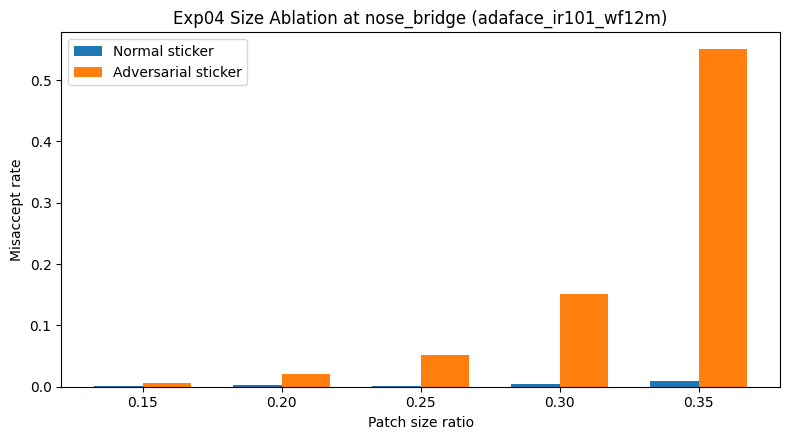

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/figures/04_size_ablation_adv_misaccept_curve.png


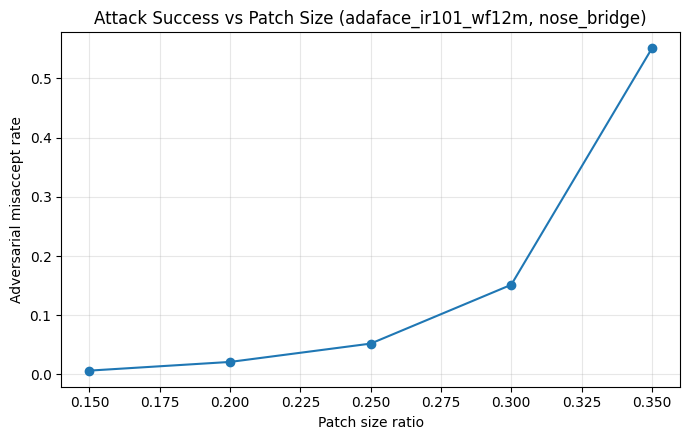

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/figures/04_size_ablation_similarity_drop_curve.png


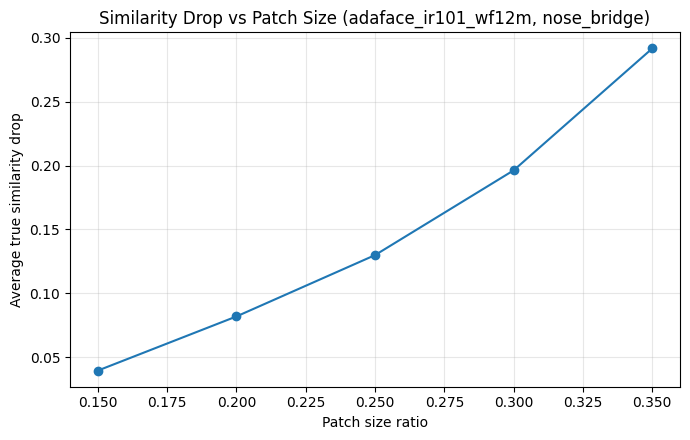

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/figures/04_size_ablation_rank1_acc_curve.png


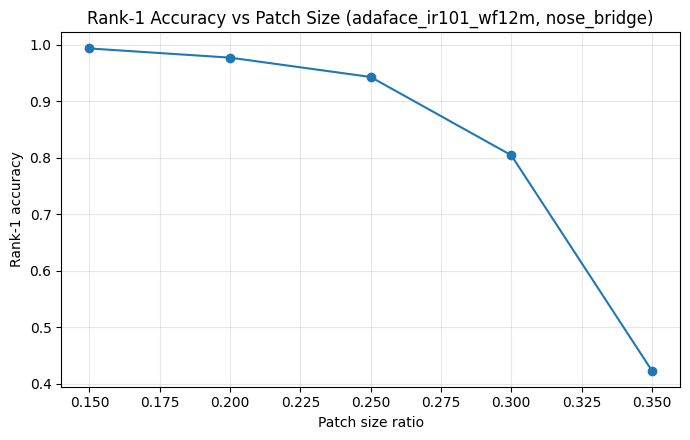

In [11]:
# ============================================================
# Cell 10. Exp04 Summary and Figures
# ============================================================

exp04_summary_df = pd.DataFrame(exp04_rows)
summary_cols = [
    "model_short_name", "condition", "placement", "n", "location",
    "patch_size_ratio", "patch_size_px", "threshold", "rank1_acc",
    "correct_accept_rate", "false_reject_rate", "misid_rate", "misaccept_rate",
    "avg_top1_sim", "avg_true_sim", "avg_similarity_drop", "run_tag",
]
for col in summary_cols:
    if col not in exp04_summary_df.columns:
        exp04_summary_df[col] = np.nan
exp04_summary_df = exp04_summary_df[summary_cols]
summary_path = EXP04_DIR / "04_size_ablation_summary.csv"
exp04_summary_df.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)
display(exp04_summary_df)

plot_df = exp04_summary_df.copy()
pivot_misaccept = plot_df.pivot(index="patch_size_ratio", columns="condition", values="misaccept_rate").reindex(EXP04_SIZE_RATIOS)

plt.figure(figsize=(8, 4.5))
x = np.arange(len(pivot_misaccept.index))
width = 0.35
plt.bar(x - width / 2, pivot_misaccept["normal_mascot_sticker"].values, width, label="Normal sticker")
plt.bar(x + width / 2, pivot_misaccept["adversarial_mascot_sticker"].values, width, label="Adversarial sticker")
plt.xticks(x, [f"{r:.2f}" for r in pivot_misaccept.index])
plt.xlabel("Patch size ratio")
plt.ylabel("Misaccept rate")
plt.title(f"Exp04 Size Ablation at {EXP04_LOCATION} ({MODEL_SHORT_NAME})")
plt.legend()
plt.tight_layout()
fig_path = EXP04_FIG_DIR / "04_size_ablation_misaccept_rate.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

adv_only_exp04 = exp04_summary_df[exp04_summary_df["condition"] == "adversarial_mascot_sticker"].copy().sort_values("patch_size_ratio")

plt.figure(figsize=(7, 4.5))
plt.plot(adv_only_exp04["patch_size_ratio"], adv_only_exp04["misaccept_rate"], marker="o")
plt.xlabel("Patch size ratio")
plt.ylabel("Adversarial misaccept rate")
plt.title(f"Attack Success vs Patch Size ({MODEL_SHORT_NAME}, {EXP04_LOCATION})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = EXP04_FIG_DIR / "04_size_ablation_adv_misaccept_curve.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(adv_only_exp04["patch_size_ratio"], adv_only_exp04["avg_similarity_drop"], marker="o")
plt.xlabel("Patch size ratio")
plt.ylabel("Average true similarity drop")
plt.title(f"Similarity Drop vs Patch Size ({MODEL_SHORT_NAME}, {EXP04_LOCATION})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = EXP04_FIG_DIR / "04_size_ablation_similarity_drop_curve.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(adv_only_exp04["patch_size_ratio"], adv_only_exp04["rank1_acc"], marker="o")
plt.xlabel("Patch size ratio")
plt.ylabel("Rank-1 accuracy")
plt.title(f"Rank-1 Accuracy vs Patch Size ({MODEL_SHORT_NAME}, {EXP04_LOCATION})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = EXP04_FIG_DIR / "04_size_ablation_rank1_acc_curve.png"
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

Best size info:
{
  "best_location": "nose_bridge",
  "best_patch_size_ratio": 0.35,
  "best_patch_size_px": 39,
  "best_misaccept_rate": 0.5504885993485342,
  "model_short_name": "adaface_ir101_wf12m",
  "exp04_run_tag": "run_20260615_141704"
}
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/figures/04_size_ablation_same_face_grid.png


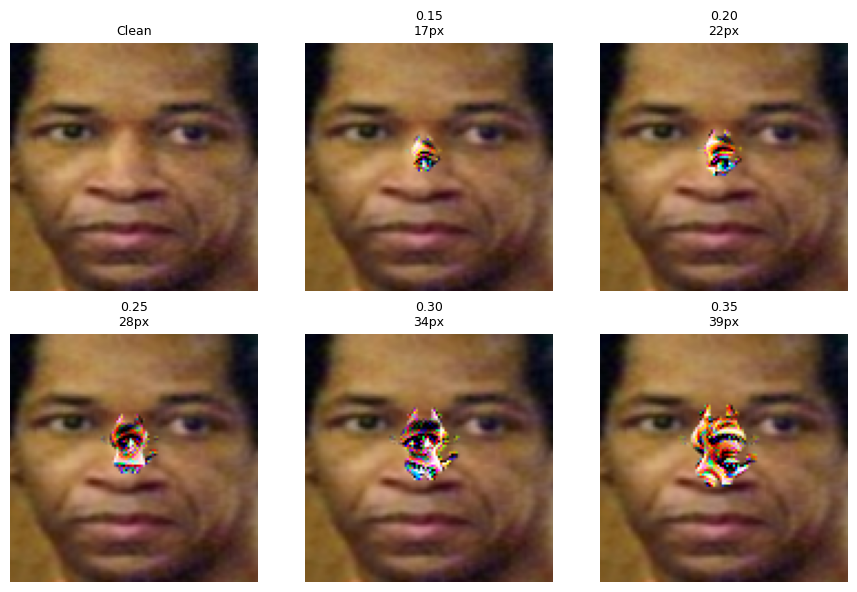

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/figures/04_best_size_random_misaccept_examples.png
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/04_best_size_random_misaccept_examples_metadata.csv


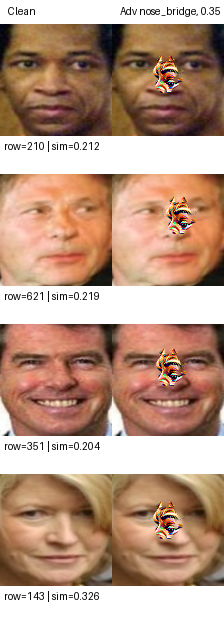

,base_probe_row,true_identity,adv_top1_identity,adv_top1_similarity,adv_true_similarity,location,patch_size_ratio,patch_size_px,misaccept
0,210,John Allen Muhammad,John Stockton,0.211850,0.110268,nose_bridge,0.35,39,True
1,621,Roman Polanski,Victoria Clarke,0.219157,0.065242,nose_bridge,0.35,39,True
2,351,Pierce Brosnan,Carla Del Ponte,0.203597,0.175837,nose_bridge,0.35,39,True
3,143,Martha Stewart,Victoria Clarke,0.326451,0.047548,nose_bridge,0.35,39,True


In [12]:
# ============================================================
# Cell 11. Best Size and Qualitative Figures
# ============================================================

best_size_row = adv_only_exp04.sort_values("misaccept_rate", ascending=False).iloc[0]
EXP04_BEST_SIZE_RATIO = float(best_size_row["patch_size_ratio"])
EXP04_BEST_SIZE_TAG = ratio_to_tag(EXP04_BEST_SIZE_RATIO)
EXP04_BEST_SIZE_PX = int(best_size_row["patch_size_px"])
EXP04_BEST_MISACCEPT = float(best_size_row["misaccept_rate"])

best_size_info = {
    "best_location": EXP04_LOCATION,
    "best_patch_size_ratio": EXP04_BEST_SIZE_RATIO,
    "best_patch_size_px": EXP04_BEST_SIZE_PX,
    "best_misaccept_rate": EXP04_BEST_MISACCEPT,
    "model_short_name": MODEL_SHORT_NAME,
    "exp04_run_tag": RUN_TAG,
}
with open(EXP04_DIR / "04_best_size.json", "w", encoding="utf-8") as f:
    json.dump(best_size_info, f, ensure_ascii=False, indent=2)
print("Best size info:")
print(json.dumps(best_size_info, indent=2, ensure_ascii=False))

# 같은 얼굴에 size별 adversarial sticker 부착
best_detail = exp04_details.get((EXP04_BEST_SIZE_TAG, "adversarial"), None)
if best_detail is not None and len(best_detail[best_detail["misaccept"] == True]) > 0:
    sample_base_idx = int(best_detail[best_detail["misaccept"] == True].sample(n=1, random_state=SEED).iloc[0]["base_probe_row"])
else:
    sample_base_idx = int(clean_eval_indices[0])

sample_item = probe_items[sample_base_idx]
sample_pil = sample_item["pil"]
sample_landmarks = sample_item.get("landmarks", CANONICAL_LANDMARKS_112)

imgs, titles = [], []
imgs.append(sample_pil.convert("RGB").resize((112, 112)))
titles.append("Clean")
for ratio in EXP04_SIZE_RATIOS:
    size_tag = ratio_to_tag(ratio)
    patch_size_px = get_patch_size_px(ratio)
    patched_img = add_patch_to_pil_for_visual(sample_pil, exp04_adv_patches[size_tag], exp04_adv_masks[size_tag], location=EXP04_LOCATION, landmarks=sample_landmarks)
    imgs.append(patched_img)
    titles.append(f"{ratio:.2f}\n{patch_size_px}px")
show_pil_grid(imgs, titles, ncols=3, figsize=(9, 6), save_path=EXP04_FIG_DIR / "04_size_ablation_same_face_grid.png")

# best size에서 random misaccept examples 4명
QUAL_NUM_EXAMPLES = 4
QUAL_RANDOM_SEED = 42
qual_detail = exp04_details.get((EXP04_BEST_SIZE_TAG, "adversarial"), None)
if qual_detail is None:
    raise ValueError("Best size detail이 없습니다.")
misaccept_df = qual_detail[qual_detail["misaccept"] == True].copy()
if len(misaccept_df) == 0:
    print("[WARN] Best size에서 misaccept 샘플이 없습니다. misidentified 샘플로 대체합니다.")
    misaccept_df = qual_detail[qual_detail["misidentified"] == True].copy()
sample_n = min(QUAL_NUM_EXAMPLES, len(misaccept_df))

if sample_n > 0:
    selected_df = misaccept_df.sample(n=sample_n, random_state=QUAL_RANDOM_SEED).reset_index(drop=True)
    adv_patch_for_qual = exp04_adv_patches[EXP04_BEST_SIZE_TAG]
    adv_mask_for_qual = exp04_adv_masks[EXP04_BEST_SIZE_TAG]
    cell_w, cell_h, header_h = 112, 150, 24
    canvas = Image.new("RGB", (cell_w * 2, header_h + cell_h * sample_n), "white")
    draw = ImageDraw.Draw(canvas)
    draw.text((8, 5), "Clean", fill=(0, 0, 0))
    draw.text((cell_w + 8, 5), f"Adv {EXP04_LOCATION}, {EXP04_BEST_SIZE_RATIO:.2f}", fill=(0, 0, 0))
    metadata_rows = []
    for r, row in enumerate(selected_df.itertuples()):
        base_idx = int(row.base_probe_row)
        item = probe_items[base_idx]
        landmarks = item.get("landmarks", CANONICAL_LANDMARKS_112)
        clean_pil = item["pil"].convert("RGB").resize((112, 112))
        adv_pil = add_patch_to_pil_for_visual(item["pil"], adv_patch_for_qual, adv_mask_for_qual, location=EXP04_LOCATION, landmarks=landmarks)
        y = header_h + r * cell_h
        canvas.paste(clean_pil, (0, y))
        canvas.paste(adv_pil, (cell_w, y))
        caption = f"row={base_idx} | sim={row.top1_similarity:.3f}"
        draw.text((4, y + 116), caption, fill=(0, 0, 0))
        metadata_rows.append({
            "base_probe_row": base_idx,
            "true_identity": row.identity,
            "adv_top1_identity": row.top1_identity,
            "adv_top1_similarity": float(row.top1_similarity),
            "adv_true_similarity": float(row.true_similarity),
            "location": EXP04_LOCATION,
            "patch_size_ratio": EXP04_BEST_SIZE_RATIO,
            "patch_size_px": EXP04_BEST_SIZE_PX,
            "misaccept": bool(row.misaccept),
        })
    qual_path = EXP04_FIG_DIR / "04_best_size_random_misaccept_examples.png"
    qual_meta_path = EXP04_DIR / "04_best_size_random_misaccept_examples_metadata.csv"
    canvas.save(qual_path)
    pd.DataFrame(metadata_rows).to_csv(qual_meta_path, index=False)
    print("Saved:", qual_path)
    print("Saved:", qual_meta_path)
    display(canvas)
    display(pd.DataFrame(metadata_rows))
else:
    print("[WARN] qualitative example로 사용할 샘플이 없습니다.")

In [13]:
# ============================================================
# Cell 12. Output Check
# ============================================================

print("Exp04 done.")
print("EXP04_DIR:", EXP04_DIR)

print("\nKey files:")
print("-", EXP04_DIR / "04_size_ablation_summary.csv")
print("-", EXP04_DIR / "04_best_size.json")
print("-", EXP04_FIG_DIR / "04_size_ablation_misaccept_rate.png")
print("-", EXP04_FIG_DIR / "04_size_ablation_adv_misaccept_curve.png")
print("-", EXP04_FIG_DIR / "04_size_ablation_similarity_drop_curve.png")
print("-", EXP04_FIG_DIR / "04_size_ablation_rank1_acc_curve.png")
print("-", EXP04_FIG_DIR / "04_size_ablation_same_face_grid.png")
print("-", EXP04_FIG_DIR / "04_best_size_random_misaccept_examples.png")

print("\nAll saved files:")
for p in sorted(EXP04_DIR.rglob("*")):
    if p.is_file():
        print("-", p.relative_to(EXP04_DIR))

Exp04 done.
EXP04_DIR: /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704

Key files:
- /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/04_size_ablation_summary.csv
- /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/04_best_size.json
- /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/figures/04_size_ablation_misaccept_rate.png
- /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/figures/04_size_ablation_adv_misaccept_curve.png
- /content/drive/MyDrive/SafeAI-final-project/output/exp04_size_ablation_only_color_lfw/adaface_ir101_wf12m/run_20260615_141704/figures/04_size_ablation_similarity_drop_curve.png
- /conte